In [72]:
import os
import re
import random
import json
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown, JSON
from IPython.display import HTML

from pprint import pprint
import rich

import fitz  # PyMuPDF
from IPython.display import display
from PIL import Image
import io
import base64

In [2]:
random.seed(42)
np.random.seed(42)

In [15]:
def json_view(
    data,
    max_chars=500,
    expanded=False,
    title="JSON Viewer"
):
    """
    Pretty, collapsible JSON viewer for VS Code / Jupyter.

    Args:
        data: dict / list / JSON-serializable object
        max_chars: truncate long JSON (None = no limit)
        expanded: whether to expand by default
        title: collapsible title
    """
    
    try:
        formatted = json.dumps(data, indent=2, ensure_ascii=False)
    except Exception as e:
        formatted = f"<<Non-serializable object: {e}>>\n{str(data)}"

    truncated = False
    if max_chars is not None and len(formatted) > max_chars:
        formatted = formatted[:max_chars] + "\n... (truncated)"
        truncated = True

    # basic syntax highlighting (lightweight)
    def highlight_json(s):
        import re
        s = re.sub(r'(\".*?\")(?=\s*:)', r'<span style="color:#9cdcfe;">\1</span>', s)  # keys
        s = re.sub(r':\s*(\".*?\")', r': <span style="color:#ce9178;">\1</span>', s)   # strings
        s = re.sub(r':\s*(\d+\.?\d*)', r': <span style="color:#b5cea8;">\1</span>', s) # numbers
        s = re.sub(r'\b(true|false|null)\b', r'<span style="color:#569cd6;">\1</span>', s)
        return s

    highlighted = highlight_json(formatted)

    open_attr = "open" if expanded else ""
    trunc_note = "<div style='color:orange;'>⚠️ Output truncated</div>" if truncated else ""

    html = f"""
    <details {open_attr} style="font-family: monospace;">
      <summary style="cursor: pointer; font-weight: bold; font-size: 14px;">
        {title}
      </summary>
      {trunc_note}
      <pre style="
        background: #1e1e1e;
        color: #d4d4d4;
        padding: 12px;
        border-radius: 6px;
        overflow-x: auto;
        font-size: 12px;
        line-height: 1.4;
      ">
{highlighted}
      </pre>
    </details>
    """

    display(HTML(html))

In [16]:
meta_file = '/work/hdd/bbkc/ma7/LiteratureReview/TileDrainageReview/Data/Bib/WOS_core/with_pdf_ris.json'
MinerU_folder = '/work/hdd/bbkc/ma7/LiteratureReview/TileDrainageReview/Data/mineru'
sample_folder = 'samples'

In [17]:
def sanitize_filename(name):
    return re.sub(r'[<>:"/\\|?*]', '_', name)

In [18]:
with open(meta_file, 'r') as f:
    meta_data = json.load(f)
len(meta_data)

1947

In [20]:
select = random.sample(meta_data, 50)
len(select)

50

In [27]:
with open(f"{sample_folder}/sample_meta.json", "w") as f:
    json.dump(select, f)

In [22]:
select[0].keys()


dict_keys(['type_of_reference', 'authors', 'title', 'secondary_title', 'language', 'keywords', 'abstract', 'author_address', 'custom3', 'unknown_tag', 'issn', 'year', 'volume', 'number', 'start_page', 'end_page', 'doi', 'accession_number', 'notes'])

In [25]:
os.makedirs(f'{sample_folder}/mineru', exist_ok=True)
for i, paper in enumerate(select):
    if i%10 == 0:
        print(f'{i}/{len(select)}')
    doi = sanitize_filename(paper['doi'])
    if os.path.exists(f"{MinerU_folder}/{doi}"):
        shutil.copytree(f"{MinerU_folder}/{doi}", f"{sample_folder}/mineru/{doi}")

0/50
10/50
20/50
30/50
40/50


## Content Display

### Meta data 

In [50]:
display_keys = [
    'type_of_reference', 'authors', 'title', 
    'secondary_title', 'doi', 'abstract', 'keywords'
]
tmp_display = {k: select[0][k] for k in display_keys}
rich.print(tmp_display)


{
    'type_of_reference': 'JOUR',
    'authors': ['Madramootoo, CA', 'Essien, M', 'Ekwuknife, K'],
    'title': 'L ONG-T ERM B ENEFITS OF C ONTROLLED D RAINAGE',
    'secondary_title': 'JOURNAL OF THE ASABE',
    'doi': '10.13031/ja.15542',
    'abstract': '. Conventional tile drainage is essential for crop production in Eastern Canada. It is of 
increasing interest for cereal and grain producers, especially in light of potential agronomic and environmental 
benefits. Based on data collected over a 13-year period at an intensive maize production site in southern Quebec, 
we found that controlled drainage has an overall positive effect on grain yield. In some years, depending on 
precipitation intensities and timing, nitrous oxide (N2O) fluxes under controlled drainage were greater than under 
conventional tile drainage. In other years, controlled drainage had 43% lower N2O emissions. Controlled drainage 
significantly reduced NO3-N contamination and tended to increase crop yield. It can be a beneficial management 
practice to be adopted on subsurface-drained croplands.',
    'keywords': [
        'Controlled drainage',
        'Crop yield',
        'Environment',
        'Greenhouse gases',
        'Subsurface drainage',
        'Water quality',
        'WATER-TABLE MANAGEMENT',
        'SANDY LOAM SOIL',
        'TILE DRAINAGE',
        'CROP YIELDS',
        'CORN',
        'NITROGEN',
        'N2O',
        'DENITRIFICATION',
        'FLUXES',
        'SUBIRRIGATION'
    ]
}

### PDF

In [59]:
display_doi = sanitize_filename(select[0]['doi'])
layout_pdf_path = f"{sample_folder}/mineru/{display_doi}/vlm/{display_doi}_layout.pdf"
original_pdf_path = f"{sample_folder}/mineru/{display_doi}/vlm/{display_doi}_origin.pdf"

#### Original

In [75]:
def show_pdf(pdf_path, zoom=1.5, page=None, display=True):
    doc = fitz.open(pdf_path)
    n_pages = len(doc)
    if page is None:
        page = 0
    else:
        if page > n_pages:
            raise ValueError(f"Page {page} is out of range for {pdf_path}")
        page = page - 1
    page = doc.load_page(page)
    pix = page.get_pixmap(matrix=fitz.Matrix(zoom, zoom))
    img_bytes = pix.tobytes("png")
    b64 = base64.b64encode(img_bytes).decode("utf-8")
    img = Image.open(io.BytesIO(pix.tobytes("png")))
    if display:
        display(img)
    return b64

In [76]:
def display_pdf(b64s):
    n = len(b64s)
    imgs_html = ""
    for b64 in b64s:
        imgs_html += f"""
        <div style="flex:1; text-align:center;">
            <div style="font-size:12px; margin-bottom:4px;">Page *</div>
            <img src="data:image/png;base64,{b64}" 
                 style="max-width:100%; border:1px solid #ccc;"/>
        </div>
        """

    html = f"""
    <div style="display:flex; gap:10px;">
        {imgs_html}
    </div>
    """
    
    display(HTML(html))

In [77]:
b64_origin = show_pdf(original_pdf_path, zoom=0.7, display=False)
b64_layout = show_pdf(layout_pdf_path, zoom=0.7, display=False)


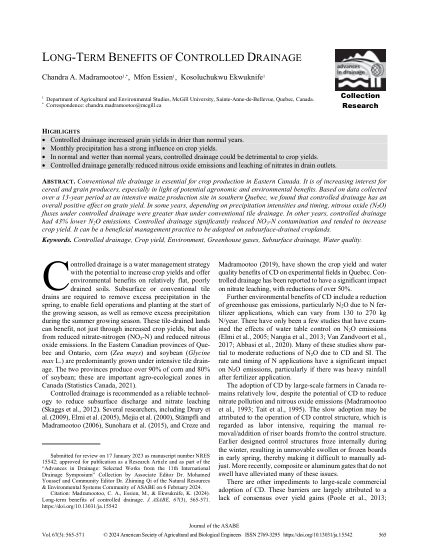
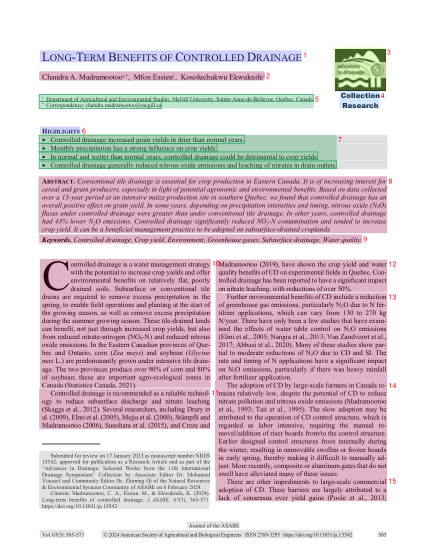

In [78]:
display_pdf([b64_origin, b64_layout])

### Markdown

In [90]:
# from IPython.display import display, HTML

def display_text_compact(text, font_size="12px", max_height="300px"):
    # from IPython.display import display, HTML
    
    display(HTML(f"""
    <div style="
        font-size: {font_size};
        line-height: 1.4;
        max-height: {max_height};
        overflow-y: auto;
        border: 1px solid #ddd;
        padding: 10px;
        border-radius: 6px;
        background: #fafafa;
        white-space: pre-wrap;
    ">
        {text}
    </div>
    """))

In [91]:
markdown_path = f"{sample_folder}/mineru/{display_doi}/vlm/{display_doi}.md"

In [92]:
with open(markdown_path, 'r') as f:
    markdown_content = f.read()
# display(Markdown(markdown_content[:2000]))
display_text_compact(markdown_content[:3000], font_size="15px")